In [14]:
# ============================================================
# 1. LOAD AND VERIFY DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the original dataset
df = pd.read_csv("heart.csv")

# Basic verification
print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully
Rows: 1025
Columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [15]:
# ============================================================
# 2. DATASET QUALITY INSPECTION
# ============================================================

print("=" * 60)
print("DATASET QUALITY INSPECTION")
print("=" * 60)

print("\n1. Data types:")
display(df.dtypes)

print("\n2. Missing values:")
display(df.isnull().sum())

duplicate_count = df.duplicated().sum()

print(f"\n3. Duplicate rows: {duplicate_count}")
print(f"   Duplicate percentage: {(duplicate_count / len(df)) * 100:.2f}%")

print("\n4. Target distribution:")
display(df["target"].value_counts().sort_index())

print("\nTarget distribution (%):")
display(
    (df["target"].value_counts(normalize=True).sort_index() * 100).round(2)
)

print("\n5. Number of unique values:")
unique_counts = df.nunique().sort_index()
display(unique_counts.to_frame("Unique Values"))

print("\n6. Descriptive statistics:")
display(df.describe().round(2))

DATASET QUALITY INSPECTION

1. Data types:


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


2. Missing values:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


3. Duplicate rows: 723
   Duplicate percentage: 70.54%

4. Target distribution:


...

target
0    48.68
1    51.32
Name: proportion, dtype: float64


5. Number of unique values:


,Unique Values
age,41
ca,5
chol,152
cp,4
exang,2
fbs,2
oldpeak,40
restecg,3
sex,2
slope,3



6. Descriptive statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


Correlation with target:


cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

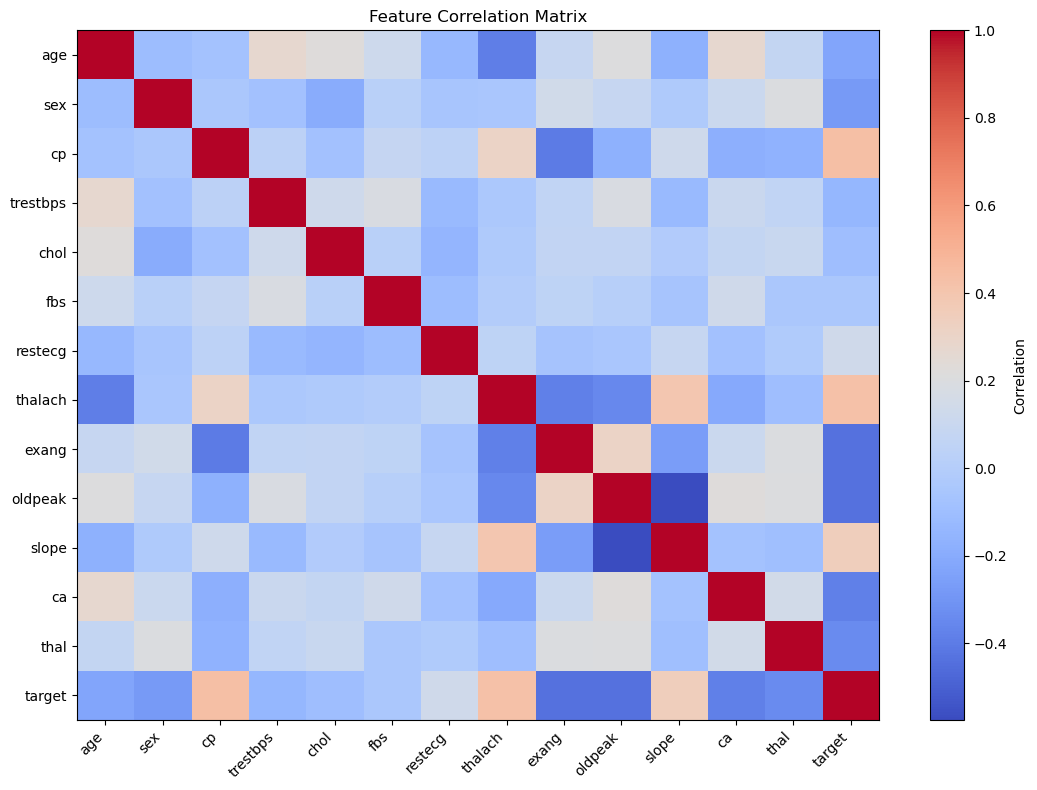

In [16]:
# ============================================================
# 3. CORRELATION ANALYSIS
# ============================================================

correlation_matrix = df.corr(numeric_only=True)

print("Correlation with target:")
display(
    correlation_matrix["target"]
    .drop("target")
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 4. FEATURE AND TARGET SEPARATION
# ============================================================

X = df.drop(columns="target")
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget classes:")
print(sorted(y.unique()))

Feature matrix shape: (1025, 13)
Target shape: (1025,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target classes:
[np.int64(0), np.int64(1)]


In [18]:
# ============================================================
# 5. TRAIN/TEST SPLIT AND SCALING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())


Training set: (820, 13)
Test set: (205, 13)

Training target distribution:
target
0    399
1    421
Name: count, dtype: int64

Test target distribution:
target
0    100
1    105
Name: count, dtype: int64


In [19]:
# ============================================================
# 6. DEFINE BASELINE MODELS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier()
}

print("Models defined:")

for name in models:
    print(f"- {name}")

Models defined:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Naive Bayes
- KNN


In [20]:
# ============================================================
# 7. BASELINE MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score)
    })

    trained_models[name] = model

baseline_results = pd.DataFrame(results)

display(
    baseline_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629


In [21]:
# ============================================================
# 8. STACKING REPRODUCTION
# ============================================================

from sklearn.ensemble import StackingClassifier

base_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),
    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "nb",
        GaussianNB()
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
]

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

stacking_model.fit(X_train_scaled, y_train)

stack_pred = stacking_model.predict(X_test_scaled)
stack_score = stacking_model.predict_proba(X_test_scaled)[:, 1]

stacking_results = pd.DataFrame([{
    "Model": "Proposed Stacking",
    "Accuracy": accuracy_score(y_test, stack_pred),
    "Precision": precision_score(y_test, stack_pred),
    "Recall": recall_score(y_test, stack_pred),
    "F1-score": f1_score(y_test, stack_pred),
    "AUC": roc_auc_score(y_test, stack_score)
}])

display(
    stacking_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Proposed Stacking,1.0000,1.0000,1.0000,1.0000,1.0000


In [22]:
# ============================================================
# 9. PUBLISHED VS REPRODUCED RESULTS
# ============================================================

# Results reported in Paper 3, Table 11
published_results = pd.DataFrame([
    ["Logistic Regression", 0.8439, 0.8196, 0.9090, 0.8620, 0.9204],
    ["Naive Bayes",         0.8439, 0.8250, 0.9000, 0.8608, 0.9185],
    ["KNN",                 0.8585, 0.8648, 0.8727, 0.8687, 0.9304],
    ["Decision Tree",       0.9268, 0.9702, 0.8909, 0.9289, 0.9702],
    ["Random Forest",       0.9268, 0.9130, 0.9545, 0.9333, 0.9734],
    ["XGBoost",             0.9073, 0.9174, 0.9090, 0.9132, 0.9830],
    ["Proposed Stacking",   0.9853, 1.0000, 0.9727, 0.9861, 0.9880]
], columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
])

# Combine our six individual models with our stacking result
reproduced_all = pd.concat(
    [baseline_results, stacking_results],
    ignore_index=True
)

# Merge published and reproduced results
comparison = published_results.merge(
    reproduced_all,
    on="Model",
    suffixes=(" (Published)", " (Reproduced)")
)

# Calculate reproduced - published difference
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]:
    comparison[f"{metric} Difference"] = (
        comparison[f"{metric} (Reproduced)"]
        - comparison[f"{metric} (Published)"]
    )

display(
    comparison.style.format({
        col: "{:.4f}"
        for col in comparison.columns
        if col != "Model"
    })
)

,Model,Accuracy (Published),Precision (Published),Recall (Published),F1-score (Published),AUC (Published),Accuracy (Reproduced),Precision (Reproduced),Recall (Reproduced),F1-score (Reproduced),AUC (Reproduced),Accuracy Difference,Precision Difference,Recall Difference,F1-score Difference,AUC Difference
0,Logistic Regression,0.8439,0.8196,0.9090,0.8620,0.9204,0.8098,0.7619,0.9143,0.8312,0.9298,-0.0341,-0.0577,0.0053,-0.0308,0.0094
1,Naive Bayes,0.8439,0.8250,0.9000,0.8608,0.9185,0.8293,0.8070,0.8762,0.8402,0.9043,-0.0146,-0.0180,-0.0238,-0.0206,-0.0142
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8634,0.8738,0.8571,0.8654,0.9629,0.0049,0.0090,-0.0156,-0.0033,0.0325
3,Decision Tree,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9714,0.9855,0.9857,0.0586,0.0298,0.0805,0.0566,0.0155
4,Random Forest,0.9268,0.9130,0.9545,0.9333,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000,0.0732,0.0870,0.0455,0.0667,0.0266
5,XGBoost,0.9073,0.9174,0.9090,0.9132,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000,0.0927,0.0826,0.0910,0.0868,0.0170
6,Proposed Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000,0.0147,0.0000,0.0273,0.0139,0.0120


In [23]:
# ============================================================
# 10. DUPLICATE AND LEAKAGE INVESTIGATION
# ============================================================

# Remove exact duplicate rows for a controlled experiment
df_unique = df.drop_duplicates().copy()

print("Original dataset size:", len(df))
print("Unique dataset size:", len(df_unique))
print("Rows removed:", len(df) - len(df_unique))

print(
    "Remaining duplicate rows:",
    df_unique.duplicated().sum()
)

print("\nTarget distribution after removing duplicates:")
display(
    df_unique["target"]
    .value_counts()
    .sort_index()
)

# Separate features and target
X_unique = df_unique.drop(columns="target")
y_unique = df_unique["target"]

# Use the same 80/20 stratified split
X_train_unique, X_test_unique, y_train_unique, y_test_unique = train_test_split(
    X_unique,
    y_unique,
    test_size=0.20,
    random_state=42,
    stratify=y_unique
)

# Fit scaling only on the training data
unique_scaler = StandardScaler()

X_train_unique_scaled = unique_scaler.fit_transform(X_train_unique)
X_test_unique_scaled = unique_scaler.transform(X_test_unique)

# Evaluate the same six baseline models
duplicate_test_results = []

for name, model in models.items():

    model.fit(X_train_unique_scaled, y_train_unique)

    y_pred = model.predict(X_test_unique_scaled)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_unique_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_unique_scaled)

    duplicate_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_unique, y_pred),
        "Precision": precision_score(y_test_unique, y_pred),
        "Recall": recall_score(y_test_unique, y_pred),
        "F1-score": f1_score(y_test_unique, y_pred),
        "AUC": roc_auc_score(y_test_unique, y_score)
    })

duplicate_test_results = pd.DataFrame(duplicate_test_results)

display(
    duplicate_test_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

Original dataset size: 1025
Unique dataset size: 302
Rows removed: 723
Remaining duplicate rows: 0

Target distribution after removing duplicates:


target
0    138
1    164
Name: count, dtype: int64

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
1,Decision Tree,0.8033,0.8182,0.8182,0.8182,0.8019
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
3,XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323
4,Naive Bayes,0.7869,0.8333,0.7576,0.7937,0.8842
5,KNN,0.7869,0.7778,0.8485,0.8116,0.8377


In [24]:
# ============================================================
# 11. BASELINE VS DUPLICATE-REMOVED COMPARISON
# ============================================================

# Rename columns to distinguish the two experiments
original_comparison = baseline_results.copy()
original_comparison = original_comparison.rename(columns={
    "Accuracy": "Accuracy (Original)",
    "Precision": "Precision (Original)",
    "Recall": "Recall (Original)",
    "F1-score": "F1-score (Original)",
    "AUC": "AUC (Original)"
})

unique_comparison = duplicate_test_results.copy()
unique_comparison = unique_comparison.rename(columns={
    "Accuracy": "Accuracy (Unique)",
    "Precision": "Precision (Unique)",
    "Recall": "Recall (Unique)",
    "F1-score": "F1-score (Unique)",
    "AUC": "AUC (Unique)"
})

duplicate_comparison = original_comparison.merge(
    unique_comparison,
    on="Model"
)

# Calculate change after removing duplicates
for metric in ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]:
    duplicate_comparison[f"{metric} Change"] = (
        duplicate_comparison[f"{metric} (Unique)"]
        - duplicate_comparison[f"{metric} (Original)"]
    )

display(
    duplicate_comparison.style.format({
        col: "{:.4f}"
        for col in duplicate_comparison.columns
        if col != "Model"
    })
)

,Model,Accuracy (Original),Precision (Original),Recall (Original),F1-score (Original),AUC (Original),Accuracy (Unique),Precision (Unique),Recall (Unique),F1-score (Unique),AUC (Unique),Accuracy Change,Precision Change,Recall Change,F1-score Change,AUC Change
0,Logistic Regression,0.8098,0.7619,0.9143,0.8312,0.9298,0.8033,0.8000,0.8485,0.8235,0.8712,-0.0065,0.0381,-0.0658,-0.0076,-0.0586
1,Decision Tree,0.9854,1.0000,0.9714,0.9855,0.9857,0.8033,0.8182,0.8182,0.8182,0.8019,-0.1821,-0.1818,-0.1532,-0.1673,-0.1838
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.7541,0.7647,0.7879,0.7761,0.8588,-0.2459,-0.2353,-0.2121,-0.2239,-0.1412
3,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,0.7213,0.7353,0.7576,0.7463,0.8323,-0.2787,-0.2647,-0.2424,-0.2537,-0.1677
4,Naive Bayes,0.8293,0.8070,0.8762,0.8402,0.9043,0.7869,0.8333,0.7576,0.7937,0.8842,-0.0424,0.0263,-0.1186,-0.0465,-0.0201
5,KNN,0.8634,0.8738,0.8571,0.8654,0.9629,0.7869,0.7778,0.8485,0.8116,0.8377,-0.0765,-0.0960,-0.0087,-0.0538,-0.1252


In [25]:
# ============================================================
# 12. CROSS-SPLIT DUPLICATE LEAKAGE CHECK
# ============================================================

# Combine features and target so we can identify identical observations
train_check = X_train.copy()
train_check["target"] = y_train.values

test_check = X_test.copy()
test_check["target"] = y_test.values

# Convert rows to tuples for exact matching
train_rows = set(map(tuple, train_check.to_numpy()))

test_duplicate_matches = [
    tuple(row) in train_rows
    for row in test_check.to_numpy()
]

duplicate_test_count = sum(test_duplicate_matches)
test_total = len(test_check)

print("=" * 60)
print("CROSS-SPLIT DUPLICATE LEAKAGE CHECK")
print("=" * 60)

print(f"\nTraining rows: {len(train_check)}")
print(f"Test rows: {len(test_check)}")
print(f"Test rows with identical training copies: {duplicate_test_count}")
print(
    f"Percentage of test rows with training duplicates: "
    f"{(duplicate_test_count / test_total) * 100:.2f}%"
)

print("\nInterpretation:")
print(
    "A matched row means an identical feature-target observation "
    "appears in both the training and test sets."
)

CROSS-SPLIT DUPLICATE LEAKAGE CHECK

Training rows: 820
Test rows: 205
Test rows with identical training copies: 202
Percentage of test rows with training duplicates: 98.54%

Interpretation:
A matched row means an identical feature-target observation appears in both the training and test sets.


In [26]:
# ============================================================
# 13. LEAKAGE-AWARE EVALUATION
# ============================================================

# Remove exact duplicates BEFORE creating the train/test split
df_clean = df.drop_duplicates().reset_index(drop=True)

X_clean = df_clean.drop(columns="target")
y_clean = df_clean["target"]

# Stratified 80/20 split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean
)

# Scale using training data only
clean_scaler = StandardScaler()

X_train_clean_scaled = clean_scaler.fit_transform(X_train_clean)
X_test_clean_scaled = clean_scaler.transform(X_test_clean)

print("=" * 60)
print("LEAKAGE-AWARE EVALUATION")
print("=" * 60)

print(f"\nClean dataset size: {len(df_clean)}")
print(f"Training rows: {len(X_train_clean)}")
print(f"Test rows: {len(X_test_clean)}")

print("\nDuplicate rows remaining:")
print(df_clean.duplicated().sum())

# Check whether any test row has an identical copy in training
train_clean_check = X_train_clean.copy()
train_clean_check["target"] = y_train_clean.values

test_clean_check = X_test_clean.copy()
test_clean_check["target"] = y_test_clean.values

train_clean_rows = set(map(tuple, train_clean_check.to_numpy()))

cross_split_matches = sum(
    tuple(row) in train_clean_rows
    for row in test_clean_check.to_numpy()
)

print(f"\nCross-split duplicate matches: {cross_split_matches}")

LEAKAGE-AWARE EVALUATION

Clean dataset size: 302
Training rows: 241
Test rows: 61

Duplicate rows remaining:
0

Cross-split duplicate matches: 0


In [27]:
# ============================================================
# 14. LEAKAGE-AWARE MODEL EVALUATION
# ============================================================

clean_results = []

for name, model in models.items():

    model.fit(X_train_clean_scaled, y_train_clean)

    y_pred = model.predict(X_test_clean_scaled)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_clean_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_clean_scaled)

    clean_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_clean, y_pred),
        "Precision": precision_score(y_test_clean, y_pred),
        "Recall": recall_score(y_test_clean, y_pred),
        "F1-score": f1_score(y_test_clean, y_pred),
        "AUC": roc_auc_score(y_test_clean, y_score)
    })

clean_results = pd.DataFrame(clean_results)

display(
    clean_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
1,Decision Tree,0.8033,0.8182,0.8182,0.8182,0.8019
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
3,XGBoost,0.7213,0.7353,0.7576,0.7463,0.8323
4,Naive Bayes,0.7869,0.8333,0.7576,0.7937,0.8842
5,KNN,0.7869,0.7778,0.8485,0.8116,0.8377


In [28]:
# ============================================================
# 15. THREE-WAY ACCURACY COMPARISON
# ============================================================

published_accuracy = published_results[
    ["Model", "Accuracy"]
].rename(
    columns={"Accuracy": "Published"}
)

original_accuracy = baseline_results[
    ["Model", "Accuracy"]
].rename(
    columns={"Accuracy": "Original Reproduction"}
)

clean_accuracy = clean_results[
    ["Model", "Accuracy"]
].rename(
    columns={"Accuracy": "Duplicate-Free"}
)

three_way_accuracy = (
    published_accuracy
    .merge(original_accuracy, on="Model")
    .merge(clean_accuracy, on="Model")
)

display(
    three_way_accuracy.style.format({
        "Published": "{:.4f}",
        "Original Reproduction": "{:.4f}",
        "Duplicate-Free": "{:.4f}"
    })
)

,Model,Published,Original Reproduction,Duplicate-Free
0,Logistic Regression,0.8439,0.8098,0.8033
1,Naive Bayes,0.8439,0.8293,0.7869
2,KNN,0.8585,0.8634,0.7869
3,Decision Tree,0.9268,0.9854,0.8033
4,Random Forest,0.9268,1.0000,0.7541
5,XGBoost,0.9073,1.0000,0.7213


In [29]:
# ============================================================
# 16. STABILITY ACROSS RANDOM SPLITS
# ============================================================

random_seeds = [1, 21, 42, 63, 84]

stability_results = []

for seed in random_seeds:

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_clean,
        y_clean,
        test_size=0.20,
        random_state=seed,
        stratify=y_clean
    )

    scaler_s = StandardScaler()

    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)

    for name, model in models.items():

        model.fit(X_train_s_scaled, y_train_s)

        y_pred_s = model.predict(X_test_s_scaled)

        if hasattr(model, "predict_proba"):
            y_score_s = model.predict_proba(X_test_s_scaled)[:, 1]
        else:
            y_score_s = model.decision_function(X_test_s_scaled)

        stability_results.append({
            "Seed": seed,
            "Model": name,
            "Accuracy": accuracy_score(y_test_s, y_pred_s),
            "Precision": precision_score(y_test_s, y_pred_s),
            "Recall": recall_score(y_test_s, y_pred_s),
            "F1-score": f1_score(y_test_s, y_pred_s),
            "AUC": roc_auc_score(y_test_s, y_score_s)
        })

stability_results = pd.DataFrame(stability_results)

print("Results across five random seeds:")
display(
    stability_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

Results across five random seeds:


,Seed,Model,Accuracy,Precision,Recall,F1-score,AUC
0,1,Logistic Regression,0.9016,0.9355,0.8788,0.9062,0.9437
1,1,Decision Tree,0.7705,0.8276,0.7273,0.7742,0.7744
2,1,Random Forest,0.8525,0.8750,0.8485,0.8615,0.9481
3,1,XGBoost,0.8361,0.8710,0.8182,0.8438,0.9242
4,1,Naive Bayes,0.8525,0.8750,0.8485,0.8615,0.9232
5,1,KNN,0.8525,0.9000,0.8182,0.8571,0.8988
6,21,Logistic Regression,0.8525,0.9000,0.8182,0.8571,0.9037
7,21,Decision Tree,0.7869,0.8333,0.7576,0.7937,0.7895
8,21,Random Forest,0.8197,0.8667,0.7879,0.8254,0.8966
9,21,XGBoost,0.8033,0.8621,0.7576,0.8065,0.8831


In [30]:
# ============================================================
# 17. MEAN AND STANDARD DEVIATION ACROSS SPLITS
# ============================================================

stability_summary = (
    stability_results
    .groupby("Model")[[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ]]
    .agg(["mean", "std"])
)

# Flatten multi-level column names
stability_summary.columns = [
    f"{metric} {stat}"
    for metric, stat in stability_summary.columns
]

display(
    stability_summary.style.format("{:.4f}")
)

,Accuracy mean,Accuracy std,Precision mean,Precision std,Recall mean,Recall std,F1-score mean,F1-score std,AUC mean,AUC std
Model,,,,,,,,,,
Decision Tree,0.7738,0.0315,0.8017,0.0400,0.7758,0.0407,0.7877,0.0283,0.7736,0.0326
KNN,0.8295,0.0395,0.8492,0.0546,0.8364,0.0271,0.8420,0.0331,0.8806,0.0464
Logistic Regression,0.8525,0.0367,0.8650,0.0582,0.8667,0.0346,0.8646,0.0306,0.9080,0.0287
Naive Bayes,0.8197,0.0307,0.8527,0.0257,0.8061,0.0460,0.8283,0.0316,0.9017,0.0198
Random Forest,0.8197,0.0449,0.8511,0.0628,0.8121,0.0254,0.8304,0.0379,0.9073,0.0408
XGBoost,0.7934,0.0427,0.8250,0.0542,0.7879,0.0303,0.8054,0.0360,0.8944,0.0413


In [31]:
# ============================================================
# 18. CROSS-VALIDATED BASELINE
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_clean,
        y_clean,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1-score Mean": scores["test_f1"].mean(),
        "AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_results)

display(
    cv_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,Logistic Regression,0.8312,0.0281,0.8380,0.8655,0.8454,0.9045
1,Decision Tree,0.7715,0.0424,0.7794,0.8110,0.7927,0.7674
2,Random Forest,0.8214,0.0329,0.8316,0.8473,0.8363,0.9066
3,XGBoost,0.8114,0.0525,0.8257,0.8290,0.8243,0.8734
4,Naive Bayes,0.8079,0.0372,0.8197,0.8354,0.8227,0.8934
5,KNN,0.8081,0.0274,0.8031,0.8598,0.8295,0.8837


In [32]:
# ============================================================
# 19. CROSS-VALIDATED STACKING BASELINE
# ============================================================

from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

stacking_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "dt",
        DecisionTreeClassifier(
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            random_state=42
        )
    ),
    (
        "xgb",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "nb",
        GaussianNB()
    ),
    (
        "knn",
        KNeighborsClassifier()
    )
]

cv_stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

stacking_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", cv_stacking)
])

stacking_cv_scores = cross_validate(
    stacking_pipeline,
    X_clean,
    y_clean,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

stacking_cv_results = pd.DataFrame([{
    "Model": "5-Fold Stacking",
    "Accuracy Mean": stacking_cv_scores["test_accuracy"].mean(),
    "Accuracy Std": stacking_cv_scores["test_accuracy"].std(),
    "Precision Mean": stacking_cv_scores["test_precision"].mean(),
    "Recall Mean": stacking_cv_scores["test_recall"].mean(),
    "F1-score Mean": stacking_cv_scores["test_f1"].mean(),
    "AUC Mean": stacking_cv_scores["test_roc_auc"].mean()
}])

display(
    stacking_cv_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,5-Fold Stacking,0.8346,0.0410,0.8332,0.8718,0.8486,0.9050


In [33]:
# ============================================================
# 20. BASELINE SUMMARY
# ============================================================

summary_results = pd.DataFrame([
    ["Published Stacking", 0.9853, np.nan, 0.9861, 0.9727, 0.9880],
    [
        "Original Reproduction",
        stacking_results["Accuracy"].iloc[0],
        np.nan,
        stacking_results["F1-score"].iloc[0],
        stacking_results["Recall"].iloc[0],
        stacking_results["AUC"].iloc[0]
    ],
    [
        "Duplicate-Free 5-Fold Stacking",
        stacking_cv_results["Accuracy Mean"].iloc[0],
        stacking_cv_results["Accuracy Std"].iloc[0],
        stacking_cv_results["F1-score Mean"].iloc[0],
        stacking_cv_results["Recall Mean"].iloc[0],
        stacking_cv_results["AUC Mean"].iloc[0]
    ]
], columns=[
    "Evaluation",
    "Accuracy",
    "Accuracy Std",
    "F1-score",
    "Recall",
    "AUC"
])

display(
    summary_results.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "F1-score": "{:.4f}",
        "Recall": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Evaluation,Accuracy,Accuracy Std,F1-score,Recall,AUC
0,Published Stacking,0.9853,nan,0.9861,0.9727,0.9880
1,Original Reproduction,1.0000,nan,1.0000,1.0000,1.0000
2,Duplicate-Free 5-Fold Stacking,0.8346,0.0410,0.8486,0.8718,0.9050


,Feature,Importance
0,cp,0.1341
1,thalach,0.1228
2,ca,0.1166
3,oldpeak,0.1106
4,thal,0.1092
5,age,0.0888
6,chol,0.0756
7,trestbps,0.0702
8,exang,0.0564
9,slope,0.0494


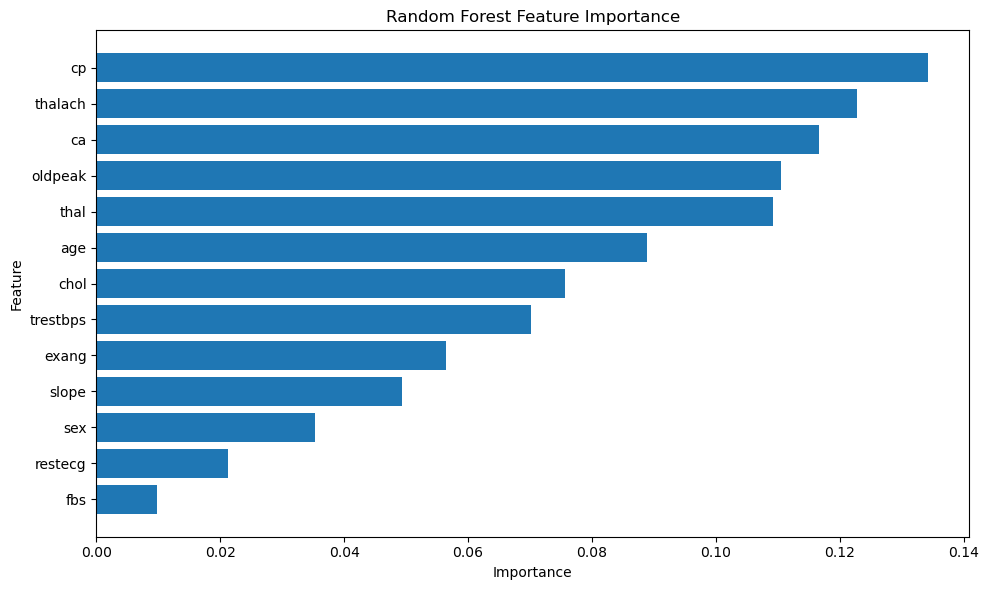

In [34]:
# ============================================================
# 21. FEATURE IMPORTANCE ANALYSIS
# ============================================================

from sklearn.ensemble import RandomForestClassifier

feature_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

feature_model.fit(
    X_clean,
    y_clean
)

feature_importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": feature_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance.style.format({
        "Importance": "{:.4f}"
    })
)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 22. SELECT CANDIDATE FEATURES
# ============================================================

importance_threshold = 0.02

selected_features = feature_importance.loc[
    feature_importance["Importance"] >= importance_threshold,
    "Feature"
].tolist()

print("Importance threshold:", importance_threshold)
print("\nSelected features:")
for feature in selected_features:
    print(f"- {feature}")

print(f"\nNumber of selected features: {len(selected_features)}")
print(f"Original number of features: {X_clean.shape[1]}")

X_selected = X_clean[selected_features]

print("\nSelected feature matrix shape:", X_selected.shape)

Importance threshold: 0.02

Selected features:
- cp
- thalach
- ca
- oldpeak
- thal
- age
- chol
- trestbps
- exang
- slope
- sex
- restecg

Number of selected features: 12
Original number of features: 13

Selected feature matrix shape: (302, 12)


In [36]:
# ============================================================
# 23. EVALUATE FEATURE-SELECTED MODELS
# ============================================================

selected_cv_results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_selected,
        y_clean,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    selected_cv_results.append({
        "Model": name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1-score Mean": scores["test_f1"].mean(),
        "AUC Mean": scores["test_roc_auc"].mean()
    })

selected_cv_results = pd.DataFrame(selected_cv_results)

display(
    selected_cv_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,Logistic Regression,0.8312,0.0281,0.8380,0.8655,0.8454,0.9049
1,Decision Tree,0.7514,0.0533,0.7607,0.7920,0.7738,0.7469
2,Random Forest,0.8114,0.0297,0.8275,0.8352,0.8267,0.9063
3,XGBoost,0.8148,0.0455,0.8275,0.8350,0.8285,0.8831
4,Naive Bayes,0.8112,0.0344,0.8270,0.8354,0.8253,0.8950
5,KNN,0.8348,0.0418,0.8222,0.8903,0.8537,0.9017


In [37]:
# ============================================================
# 24. FEATURE-SELECTED STACKING
# ============================================================

selected_stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

selected_stacking_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", selected_stacking)
])

selected_stacking_scores = cross_validate(
    selected_stacking_pipeline,
    X_selected,
    y_clean,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

selected_stacking_results = pd.DataFrame([{
    "Model": "Feature-Selected Stacking",
    "Accuracy Mean": selected_stacking_scores["test_accuracy"].mean(),
    "Accuracy Std": selected_stacking_scores["test_accuracy"].std(),
    "Precision Mean": selected_stacking_scores["test_precision"].mean(),
    "Recall Mean": selected_stacking_scores["test_recall"].mean(),
    "F1-score Mean": selected_stacking_scores["test_f1"].mean(),
    "AUC Mean": selected_stacking_scores["test_roc_auc"].mean()
}])

display(
    selected_stacking_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,Feature-Selected Stacking,0.8314,0.0387,0.8265,0.8778,0.8480,0.9143


In [38]:
# ============================================================
# 25. COMPARE STACKING VARIANTS
# ============================================================

stacking_comparison = pd.DataFrame([
    [
        "Published Stacking",
        0.9853,
        np.nan,
        0.9861,
        0.9727,
        0.9880
    ],
    [
        "Original Reproduction",
        stacking_results["Accuracy"].iloc[0],
        np.nan,
        stacking_results["F1-score"].iloc[0],
        stacking_results["Recall"].iloc[0],
        stacking_results["AUC"].iloc[0]
    ],
    [
        "Duplicate-Free 5-Fold Stacking",
        stacking_cv_results["Accuracy Mean"].iloc[0],
        stacking_cv_results["Accuracy Std"].iloc[0],
        stacking_cv_results["F1-score Mean"].iloc[0],
        stacking_cv_results["Recall Mean"].iloc[0],
        stacking_cv_results["AUC Mean"].iloc[0]
    ],
    [
        "Feature-Selected Stacking",
        selected_stacking_results["Accuracy Mean"].iloc[0],
        selected_stacking_results["Accuracy Std"].iloc[0],
        selected_stacking_results["F1-score Mean"].iloc[0],
        selected_stacking_results["Recall Mean"].iloc[0],
        selected_stacking_results["AUC Mean"].iloc[0]
    ]
], columns=[
    "Evaluation",
    "Accuracy",
    "Accuracy Std",
    "F1-score",
    "Recall",
    "AUC"
])

display(
    stacking_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "F1-score": "{:.4f}",
        "Recall": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Evaluation,Accuracy,Accuracy Std,F1-score,Recall,AUC
0,Published Stacking,0.9853,nan,0.9861,0.9727,0.9880
1,Original Reproduction,1.0000,nan,1.0000,1.0000,1.0000
2,Duplicate-Free 5-Fold Stacking,0.8346,0.0410,0.8486,0.8718,0.9050
3,Feature-Selected Stacking,0.8314,0.0387,0.8480,0.8778,0.9143


In [39]:
# ============================================================
# 26. PROPOSED DIVERSE STACKING PIPELINE
# ============================================================

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

proposed_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    ),
    (
        "xgb",
        XGBClassifier(
            n_estimators=200,
            random_state=42,
            eval_metric="logloss"
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            random_state=42
        )
    ),
    (
        "svm",
        SVC(
            probability=True,
            random_state=42
        )
    )
]

proposed_stacking = StackingClassifier(
    estimators=proposed_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

proposed_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", proposed_stacking)
])

proposed_scores = cross_validate(
    proposed_pipeline,
    X_clean,
    y_clean,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

proposed_results = pd.DataFrame([{
    "Model": "Proposed Diverse Stacking",
    "Accuracy Mean": proposed_scores["test_accuracy"].mean(),
    "Accuracy Std": proposed_scores["test_accuracy"].std(),
    "Precision Mean": proposed_scores["test_precision"].mean(),
    "Recall Mean": proposed_scores["test_recall"].mean(),
    "F1-score Mean": proposed_scores["test_f1"].mean(),
    "AUC Mean": proposed_scores["test_roc_auc"].mean()
}])

display(
    proposed_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,Proposed Diverse Stacking,0.8314,0.0387,0.8267,0.8780,0.8484,0.9071


In [40]:
# ============================================================
# 27. BASE-MODEL CONTRIBUTION ANALYSIS
# ============================================================

reduced_estimators = [
    (
        "lr",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    ),
    (
        "rf",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    ),
    (
        "gb",
        GradientBoostingClassifier(
            random_state=42
        )
    ),
    (
        "svm",
        SVC(
            probability=True,
            random_state=42
        )
    )
]

reduced_stacking = StackingClassifier(
    estimators=reduced_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

reduced_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", reduced_stacking)
])

reduced_scores = cross_validate(
    reduced_pipeline,
    X_clean,
    y_clean,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

reduced_results = pd.DataFrame([{
    "Model": "Reduced Stacking",
    "Accuracy Mean": reduced_scores["test_accuracy"].mean(),
    "Accuracy Std": reduced_scores["test_accuracy"].std(),
    "Precision Mean": reduced_scores["test_precision"].mean(),
    "Recall Mean": reduced_scores["test_recall"].mean(),
    "F1-score Mean": reduced_scores["test_f1"].mean(),
    "AUC Mean": reduced_scores["test_roc_auc"].mean()
}])

display(
    reduced_results.style.format({
        "Accuracy Mean": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "Precision Mean": "{:.4f}",
        "Recall Mean": "{:.4f}",
        "F1-score Mean": "{:.4f}",
        "AUC Mean": "{:.4f}"
    })
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1-score Mean,AUC Mean
0,Reduced Stacking,0.8314,0.0371,0.8295,0.8720,0.8466,0.9090


In [41]:
# ============================================================
# 28. FINAL MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame([
    [
        "Published Stacking",
        0.9853,
        np.nan,
        0.9861,
        0.9727,
        0.9880
    ],
    [
        "Duplicate-Free Stacking",
        stacking_cv_results["Accuracy Mean"].iloc[0],
        stacking_cv_results["Accuracy Std"].iloc[0],
        stacking_cv_results["F1-score Mean"].iloc[0],
        stacking_cv_results["Recall Mean"].iloc[0],
        stacking_cv_results["AUC Mean"].iloc[0]
    ],
    [
        "Feature-Selected Stacking",
        selected_stacking_results["Accuracy Mean"].iloc[0],
        selected_stacking_results["Accuracy Std"].iloc[0],
        selected_stacking_results["F1-score Mean"].iloc[0],
        selected_stacking_results["Recall Mean"].iloc[0],
        selected_stacking_results["AUC Mean"].iloc[0]
    ],
    [
        "Diverse Stacking",
        proposed_results["Accuracy Mean"].iloc[0],
        proposed_results["Accuracy Std"].iloc[0],
        proposed_results["F1-score Mean"].iloc[0],
        proposed_results["Recall Mean"].iloc[0],
        proposed_results["AUC Mean"].iloc[0]
    ],
    [
        "Reduced Stacking",
        reduced_results["Accuracy Mean"].iloc[0],
        reduced_results["Accuracy Std"].iloc[0],
        reduced_results["F1-score Mean"].iloc[0],
        reduced_results["Recall Mean"].iloc[0],
        reduced_results["AUC Mean"].iloc[0]
    ]
], columns=[
    "Evaluation",
    "Accuracy",
    "Accuracy Std",
    "F1-score",
    "Recall",
    "AUC"
])

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "F1-score": "{:.4f}",
        "Recall": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Evaluation,Accuracy,Accuracy Std,F1-score,Recall,AUC
0,Published Stacking,0.9853,nan,0.9861,0.9727,0.9880
1,Duplicate-Free Stacking,0.8346,0.0410,0.8486,0.8718,0.9050
2,Feature-Selected Stacking,0.8314,0.0387,0.8480,0.8778,0.9143
3,Diverse Stacking,0.8314,0.0387,0.8484,0.8780,0.9071
4,Reduced Stacking,0.8314,0.0371,0.8466,0.8720,0.9090


In [42]:
# ============================================================
# 29. CROSS-VALIDATION FOLD RESULTS
# ============================================================

baseline_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": stacking_cv_scores["test_accuracy"],
    "Precision": stacking_cv_scores["test_precision"],
    "Recall": stacking_cv_scores["test_recall"],
    "F1-score": stacking_cv_scores["test_f1"],
    "AUC": stacking_cv_scores["test_roc_auc"]
})

proposed_fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": proposed_scores["test_accuracy"],
    "Precision": proposed_scores["test_precision"],
    "Recall": proposed_scores["test_recall"],
    "F1-score": proposed_scores["test_f1"],
    "AUC": proposed_scores["test_roc_auc"]
})

print("=" * 60)
print("DUPLICATE-FREE BASELINE STACKING - FOLD RESULTS")
print("=" * 60)

display(
    baseline_fold_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

print("\n" + "=" * 60)
print("PROPOSED DIVERSE STACKING - FOLD RESULTS")
print("=" * 60)

display(
    proposed_fold_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

DUPLICATE-FREE BASELINE STACKING - FOLD RESULTS


,Fold,Accuracy,Precision,Recall,F1-score,AUC
0,1,0.7705,0.8519,0.6970,0.7667,0.8799
1,2,0.8361,0.7949,0.9394,0.8611,0.9286
2,3,0.8333,0.8438,0.8438,0.8438,0.9007
3,4,0.9000,0.8649,0.9697,0.9143,0.9125
4,5,0.8333,0.8108,0.9091,0.8571,0.9035



PROPOSED DIVERSE STACKING - FOLD RESULTS


,Fold,Accuracy,Precision,Recall,F1-score,AUC
0,1,0.7869,0.8571,0.7273,0.7869,0.8680
1,2,0.8033,0.7561,0.9394,0.8378,0.9340
2,3,0.8333,0.8235,0.8750,0.8485,0.9018
3,4,0.9000,0.8857,0.9394,0.9118,0.9136
4,5,0.8333,0.8108,0.9091,0.8571,0.9181


In [43]:
# ============================================================
# 30. STATISTICAL COMPARISON OF STACKING APPROACHES
# ============================================================

from scipy.stats import ttest_rel

comparison_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
]

statistical_results = []

for metric in comparison_metrics:

    baseline_values = baseline_fold_results[metric].values
    proposed_values = proposed_fold_results[metric].values

    differences = proposed_values - baseline_values

    t_stat, p_value = ttest_rel(
        proposed_values,
        baseline_values
    )

    statistical_results.append({
        "Metric": metric,
        "Baseline Mean": baseline_values.mean(),
        "Proposed Mean": proposed_values.mean(),
        "Mean Difference": differences.mean(),
        "Difference Std": differences.std(ddof=1),
        "t-statistic": t_stat,
        "p-value": p_value
    })

statistical_results = pd.DataFrame(statistical_results)

display(
    statistical_results.style.format({
        "Baseline Mean": "{:.4f}",
        "Proposed Mean": "{:.4f}",
        "Mean Difference": "{:.4f}",
        "Difference Std": "{:.4f}",
        "t-statistic": "{:.4f}",
        "p-value": "{:.4f}"
    })
)

,Metric,Baseline Mean,Proposed Mean,Mean Difference,Difference Std,t-statistic,p-value
0,Accuracy,0.8346,0.8314,-0.0033,0.0180,-0.4082,0.7040
1,Precision,0.8332,0.8267,-0.0066,0.0232,-0.6324,0.5615
2,Recall,0.8718,0.8780,0.0063,0.0256,0.5463,0.6139
3,F1-score,0.8486,0.8484,-0.0002,0.0156,-0.0240,0.9820
4,AUC,0.9050,0.9071,0.0021,0.0096,0.4838,0.6538


In [44]:
# ============================================================
# 31. FINAL EVALUATION SUMMARY
# ============================================================

final_evaluation = pd.DataFrame([
    [
        "Published Paper",
        0.9853,
        np.nan,
        0.9861,
        0.9727,
        0.9880
    ],
    [
        "Original Reproduction",
        stacking_results["Accuracy"].iloc[0],
        np.nan,
        stacking_results["F1-score"].iloc[0],
        stacking_results["Recall"].iloc[0],
        stacking_results["AUC"].iloc[0]
    ],
    [
        "Duplicate-Free Baseline",
        stacking_cv_results["Accuracy Mean"].iloc[0],
        stacking_cv_results["Accuracy Std"].iloc[0],
        stacking_cv_results["F1-score Mean"].iloc[0],
        stacking_cv_results["Recall Mean"].iloc[0],
        stacking_cv_results["AUC Mean"].iloc[0]
    ],
    [
        "Proposed Diverse Stacking",
        proposed_results["Accuracy Mean"].iloc[0],
        proposed_results["Accuracy Std"].iloc[0],
        proposed_results["F1-score Mean"].iloc[0],
        proposed_results["Recall Mean"].iloc[0],
        proposed_results["AUC Mean"].iloc[0]
    ]
], columns=[
    "Evaluation",
    "Accuracy",
    "Accuracy Std",
    "F1-score",
    "Recall",
    "AUC"
])

display(
    final_evaluation.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy Std": "{:.4f}",
        "F1-score": "{:.4f}",
        "Recall": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Evaluation,Accuracy,Accuracy Std,F1-score,Recall,AUC
0,Published Paper,0.9853,nan,0.9861,0.9727,0.9880
1,Original Reproduction,1.0000,nan,1.0000,1.0000,1.0000
2,Duplicate-Free Baseline,0.8346,0.0410,0.8486,0.8718,0.9050
3,Proposed Diverse Stacking,0.8314,0.0387,0.8484,0.8780,0.9071


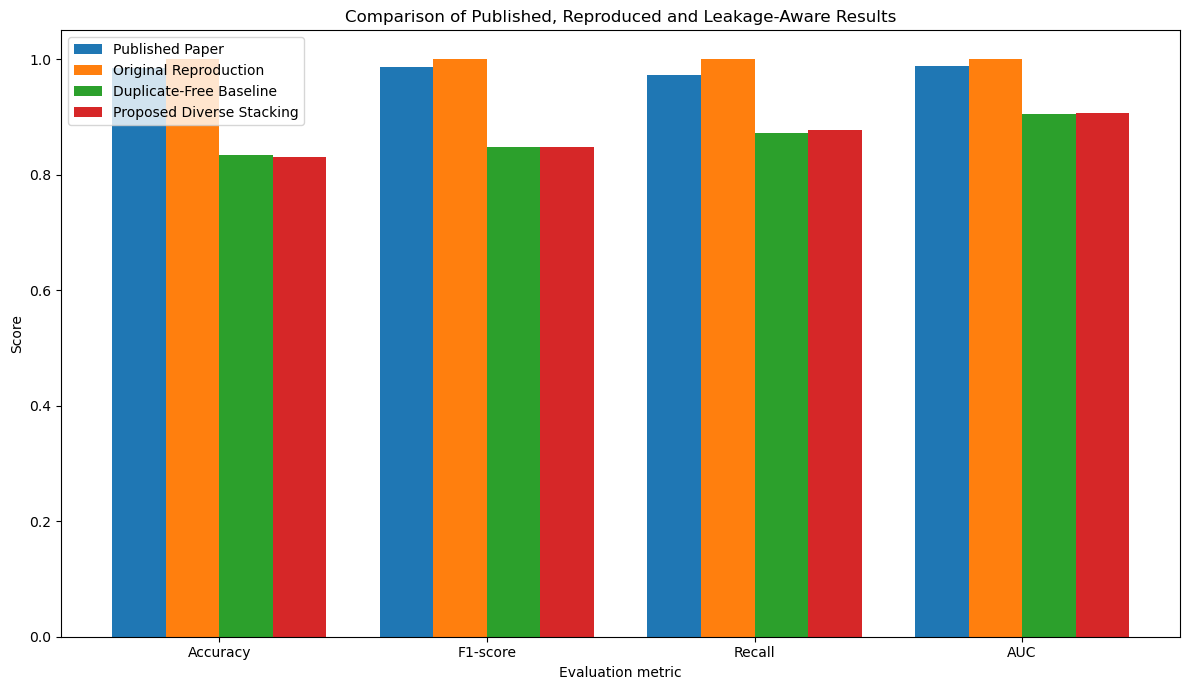

In [45]:
# ============================================================
# 32. FINAL RESULTS VISUALISATION
# ============================================================

plot_data = final_evaluation.copy()

metrics = ["Accuracy", "F1-score", "Recall", "AUC"]

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12, 7))

for i, row in plot_data.iterrows():
    values = [row[metric] for metric in metrics]

    if row["Evaluation"] == "Published Paper":
        label = "Published Paper"
    elif row["Evaluation"] == "Original Reproduction":
        label = "Original Reproduction"
    elif row["Evaluation"] == "Duplicate-Free Baseline":
        label = "Duplicate-Free Baseline"
    else:
        label = "Proposed Diverse Stacking"

    plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=label
    )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Evaluation metric")
plt.title("Comparison of Published, Reproduced and Leakage-Aware Results")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

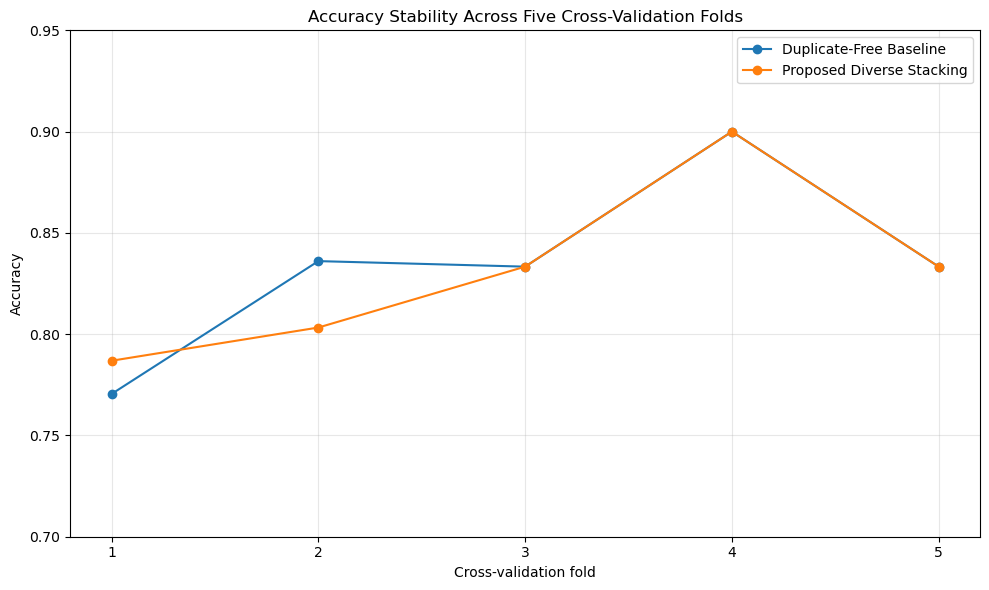

In [47]:
# ============================================================
# 33. CROSS-VALIDATION STABILITY VISUALISATION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    baseline_fold_results["Fold"],
    baseline_fold_results["Accuracy"],
    marker="o",
    label="Duplicate-Free Baseline"
)

plt.plot(
    proposed_fold_results["Fold"],
    proposed_fold_results["Accuracy"],
    marker="o",
    label="Proposed Diverse Stacking"
)

plt.xticks(range(1, 6))
plt.xlabel("Cross-validation fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Stability Across Five Cross-Validation Folds")
plt.ylim(0.70, 0.95)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PROPOSED MODEL HOLDOUT EVALUATION

Confusion Matrix:
[[20  8]
 [ 7 26]]

TN: 20
FP: 8
FN: 7
TP: 26

Holdout Metrics:
Accuracy : 0.7541
Precision: 0.7647
Recall   : 0.7879
F1-score : 0.7761
AUC      : 0.8658


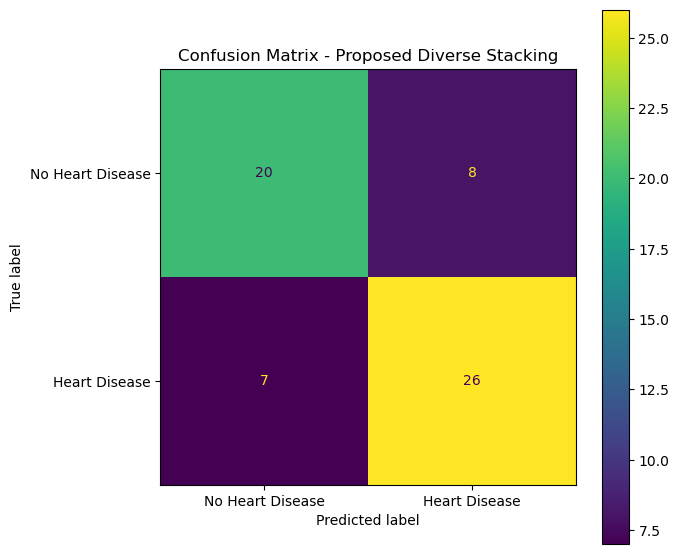

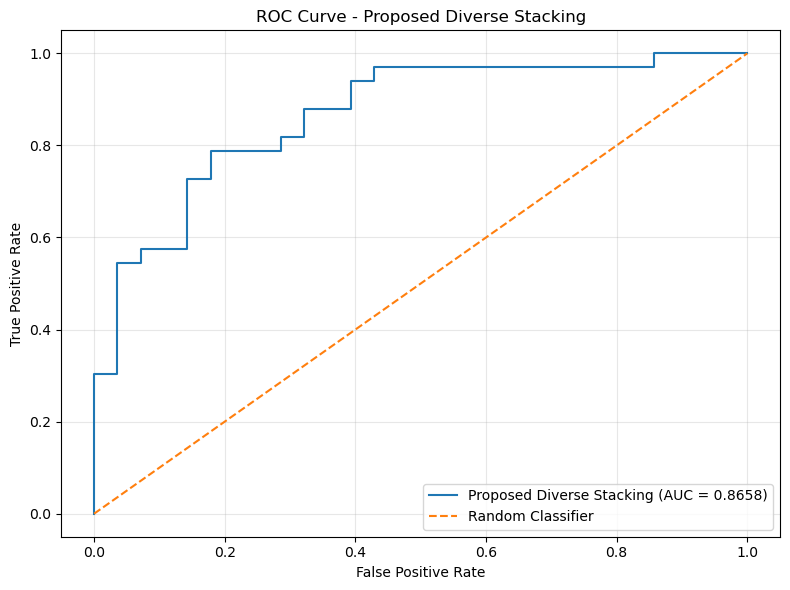

In [48]:
# ============================================================
# 34. CONFUSION MATRIX AND ROC CURVE
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Train proposed model on the duplicate-free training set
proposed_pipeline.fit(
    X_train_clean,
    y_train_clean
)

# Predictions and probability scores
final_pred = proposed_pipeline.predict(X_test_clean)
final_prob = proposed_pipeline.predict_proba(X_test_clean)[:, 1]

# Confusion matrix
cm = confusion_matrix(
    y_test_clean,
    final_pred
)

print("=" * 60)
print("PROPOSED MODEL HOLDOUT EVALUATION")
print("=" * 60)

print("\nConfusion Matrix:")
print(cm)

print("\nTN:", cm[0, 0])
print("FP:", cm[0, 1])
print("FN:", cm[1, 0])
print("TP:", cm[1, 1])

print("\nHoldout Metrics:")
print(f"Accuracy : {accuracy_score(y_test_clean, final_pred):.4f}")
print(f"Precision: {precision_score(y_test_clean, final_pred):.4f}")
print(f"Recall   : {recall_score(y_test_clean, final_pred):.4f}")
print(f"F1-score : {f1_score(y_test_clean, final_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test_clean, final_prob):.4f}")

# Confusion matrix figure
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
).plot(ax=plt.gca())

plt.title("Confusion Matrix - Proposed Diverse Stacking")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test_clean,
    final_prob
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Proposed Diverse Stacking (AUC = {roc_auc_score(y_test_clean, final_prob):.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Proposed Diverse Stacking")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# 35. HOLDOUT BASELINE VS PROPOSED MODEL
# ============================================================

# Baseline stacking model
baseline_holdout_stacking = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

baseline_holdout_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("stacking", baseline_holdout_stacking)
])

# Train both models on exactly the same duplicate-free split
baseline_holdout_pipeline.fit(
    X_train_clean,
    y_train_clean
)

proposed_pipeline.fit(
    X_train_clean,
    y_train_clean
)

# Predictions
baseline_holdout_pred = baseline_holdout_pipeline.predict(X_test_clean)
baseline_holdout_prob = baseline_holdout_pipeline.predict_proba(
    X_test_clean
)[:, 1]

proposed_holdout_pred = proposed_pipeline.predict(X_test_clean)
proposed_holdout_prob = proposed_pipeline.predict_proba(
    X_test_clean
)[:, 1]

# Results
holdout_comparison = pd.DataFrame([
    {
        "Model": "Duplicate-Free Baseline",
        "Accuracy": accuracy_score(
            y_test_clean,
            baseline_holdout_pred
        ),
        "Precision": precision_score(
            y_test_clean,
            baseline_holdout_pred
        ),
        "Recall": recall_score(
            y_test_clean,
            baseline_holdout_pred
        ),
        "F1-score": f1_score(
            y_test_clean,
            baseline_holdout_pred
        ),
        "AUC": roc_auc_score(
            y_test_clean,
            baseline_holdout_prob
        )
    },
    {
        "Model": "Proposed Diverse Stacking",
        "Accuracy": accuracy_score(
            y_test_clean,
            proposed_holdout_pred
        ),
        "Precision": precision_score(
            y_test_clean,
            proposed_holdout_pred
        ),
        "Recall": recall_score(
            y_test_clean,
            proposed_holdout_pred
        ),
        "F1-score": f1_score(
            y_test_clean,
            proposed_holdout_pred
        ),
        "AUC": roc_auc_score(
            y_test_clean,
            proposed_holdout_prob
        )
    }
])

display(
    holdout_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Duplicate-Free Baseline,0.7541,0.7647,0.7879,0.7761,0.8680
1,Proposed Diverse Stacking,0.7541,0.7647,0.7879,0.7761,0.8658


In [50]:
# ============================================================
# 36. QUANTIFY REPRODUCIBILITY GAP
# ============================================================

reproducibility_gap = pd.DataFrame([
    [
        "Accuracy",
        0.9853,
        stacking_cv_results["Accuracy Mean"].iloc[0],
        stacking_cv_results["Accuracy Mean"].iloc[0] - 0.9853
    ],
    [
        "F1-score",
        0.9861,
        stacking_cv_results["F1-score Mean"].iloc[0],
        stacking_cv_results["F1-score Mean"].iloc[0] - 0.9861
    ],
    [
        "Recall",
        0.9727,
        stacking_cv_results["Recall Mean"].iloc[0],
        stacking_cv_results["Recall Mean"].iloc[0] - 0.9727
    ],
    [
        "AUC",
        0.9880,
        stacking_cv_results["AUC Mean"].iloc[0],
        stacking_cv_results["AUC Mean"].iloc[0] - 0.9880
    ]
], columns=[
    "Metric",
    "Published",
    "Duplicate-Free 5-Fold",
    "Difference"
])

display(
    reproducibility_gap.style.format({
        "Published": "{:.4f}",
        "Duplicate-Free 5-Fold": "{:.4f}",
        "Difference": "{:.4f}"
    })
)

,Metric,Published,Duplicate-Free 5-Fold,Difference
0,Accuracy,0.9853,0.8346,-0.1507
1,F1-score,0.9861,0.8486,-0.1375
2,Recall,0.9727,0.8718,-0.1009
3,AUC,0.9880,0.9050,-0.0830


In [51]:
# ============================================================
# 37. FINAL NOTEBOOK SUMMARY
# ============================================================

notebook_summary = pd.DataFrame([
    [
        "Paper reproduction",
        "Original dataset and stacking implementation",
        "1.0000",
        "Original duplicated dataset"
    ],
    [
        "Duplicate-free evaluation",
        "Removed exact duplicate observations",
        "0.8346",
        "5-fold cross-validation"
    ],
    [
        "Feature-selected stacking",
        "Removed low-importance feature",
        "0.8314",
        "5-fold cross-validation"
    ],
    [
        "Diverse stacking",
        "Alternative base-model composition",
        "0.8314",
        "5-fold cross-validation"
    ],
    [
        "Statistical comparison",
        "Paired comparison across identical folds",
        "p > 0.05",
        "No significant difference"
    ]
], columns=[
    "Experiment",
    "Method",
    "Key Result",
    "Evaluation"
])

display(notebook_summary)

,Experiment,Method,Key Result,Evaluation
0,Paper reproduction,Original dataset and stacking implementation,1.0000,Original duplicated dataset
1,Duplicate-free evaluation,Removed exact duplicate observations,0.8346,5-fold cross-validation
2,Feature-selected stacking,Removed low-importance feature,0.8314,5-fold cross-validation
3,Diverse stacking,Alternative base-model composition,0.8314,5-fold cross-validation
4,Statistical comparison,Paired comparison across identical folds,p > 0.05,No significant difference


In [52]:
# ============================================================
# 38. LEAKAGE-AWARE FEATURE SELECTION
# ============================================================

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate

# Use the duplicate-free dataset
X_clean = df_clean.drop(columns="target")
y_clean = df_clean["target"]

# Same 5-fold protocol used for the baseline
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Feature selection is placed INSIDE the pipeline.
# Therefore, feature selection is fitted separately within each
# training fold and does not use information from the validation fold.
feature_selector = SelectKBest(
    score_func=f_classif,
    k=8
)

base_estimators = [
    ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    )),
    ("gb", GradientBoostingClassifier(random_state=42)),
    ("svm", SVC(
        probability=True,
        random_state=42
    ))
]

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    stack_method="predict_proba"
)

leakage_aware_pipeline = Pipeline([
    ("feature_selection", feature_selector),
    ("scaling", StandardScaler()),
    ("stacking", stacking_model)
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc"
}

results = cross_validate(
    leakage_aware_pipeline,
    X_clean,
    y_clean,
    cv=cv,
    scoring=scoring
)

print("LEAKAGE-AWARE FEATURE-SELECTED STACKING")
print("=" * 55)
print(f"Selected features per fold: 8")
print(f"Accuracy : {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"Precision: {results['test_precision'].mean():.4f}")
print(f"Recall   : {results['test_recall'].mean():.4f}")
print(f"F1-score : {results['test_f1'].mean():.4f}")
print(f"AUC      : {results['test_auc'].mean():.4f}")

LEAKAGE-AWARE FEATURE-SELECTED STACKING
Selected features per fold: 8
Accuracy : 0.8445 ± 0.0302
Precision: 0.8423
Recall   : 0.8902
F1-score : 0.8610
AUC      : 0.9102


In [53]:
# ============================================================
# 39. FOLD-LEVEL STATISTICAL COMPARISON
# ============================================================

from scipy.stats import ttest_rel

# Reuse the same five folds for both models
baseline_pipeline = Pipeline([
    ("scaling", StandardScaler()),
    ("stacking", StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=42)),
            ("rf", RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )),
            ("xgb", XGBClassifier(
                n_estimators=200,
                random_state=42,
                eval_metric="logloss"
            ))
        ],
        final_estimator=LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        cv=5,
        stack_method="predict_proba"
    ))
])

# Store fold-level results
baseline_fold_results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

proposed_fold_results = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for train_idx, test_idx in cv.split(X_clean, y_clean):

    X_train, X_test = X_clean.iloc[train_idx], X_clean.iloc[test_idx]
    y_train, y_test = y_clean.iloc[train_idx], y_clean.iloc[test_idx]

    # Baseline
    baseline_pipeline.fit(X_train, y_train)
    baseline_pred = baseline_pipeline.predict(X_test)
    baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

    baseline_fold_results["accuracy"].append(
        accuracy_score(y_test, baseline_pred)
    )
    baseline_fold_results["precision"].append(
        precision_score(y_test, baseline_pred)
    )
    baseline_fold_results["recall"].append(
        recall_score(y_test, baseline_pred)
    )
    baseline_fold_results["f1"].append(
        f1_score(y_test, baseline_pred)
    )
    baseline_fold_results["auc"].append(
        roc_auc_score(y_test, baseline_prob)
    )

    # Proposed leakage-aware feature-selected stacking
    leakage_aware_pipeline.fit(X_train, y_train)
    proposed_pred = leakage_aware_pipeline.predict(X_test)
    proposed_prob = leakage_aware_pipeline.predict_proba(X_test)[:, 1]

    proposed_fold_results["accuracy"].append(
        accuracy_score(y_test, proposed_pred)
    )
    proposed_fold_results["precision"].append(
        precision_score(y_test, proposed_pred)
    )
    proposed_fold_results["recall"].append(
        recall_score(y_test, proposed_pred)
    )
    proposed_fold_results["f1"].append(
        f1_score(y_test, proposed_pred)
    )
    proposed_fold_results["auc"].append(
        roc_auc_score(y_test, proposed_prob)
    )

# Paired t-tests
metrics = ["accuracy", "precision", "recall", "f1", "auc"]

print("PAIRED STATISTICAL COMPARISON")
print("=" * 65)

for metric in metrics:

    baseline_values = baseline_fold_results[metric]
    proposed_values = proposed_fold_results[metric]

    statistic, p_value = ttest_rel(
        proposed_values,
        baseline_values
    )

    difference = np.mean(proposed_values) - np.mean(baseline_values)

    print(
        f"{metric.upper():10s} | "
        f"Baseline: {np.mean(baseline_values):.4f} | "
        f"Proposed: {np.mean(proposed_values):.4f} | "
        f"Difference: {difference:+.4f} | "
        f"p-value: {p_value:.4f}"
    )

PAIRED STATISTICAL COMPARISON
ACCURACY   | Baseline: 0.8214 | Proposed: 0.8445 | Difference: +0.0231 | p-value: 0.1083
PRECISION  | Baseline: 0.8199 | Proposed: 0.8423 | Difference: +0.0224 | p-value: 0.2068
RECALL     | Baseline: 0.8657 | Proposed: 0.8902 | Difference: +0.0244 | p-value: 0.0162
F1         | Baseline: 0.8390 | Proposed: 0.8610 | Difference: +0.0220 | p-value: 0.0887
AUC        | Baseline: 0.9075 | Proposed: 0.9102 | Difference: +0.0027 | p-value: 0.8021


In [54]:
# ============================================================
# 40. CONTROLLED BASELINE VS PROPOSED COMPARISON
# ============================================================

# Exact six-model stacking configuration used in the original reproduction
exact_base_estimators = [
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
    ("dt", DecisionTreeClassifier(
        random_state=42
    )),
    ("rf", RandomForestClassifier(
        random_state=42
    )),
    ("xgb", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )),
    ("nb", GaussianNB()),
    ("knn", KNeighborsClassifier())
]

exact_baseline_stacking = StackingClassifier(
    estimators=exact_base_estimators,
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    cv=5,
    stack_method="predict_proba"
)

exact_baseline_pipeline = Pipeline([
    ("scaling", StandardScaler()),
    ("stacking", exact_baseline_stacking)
])

controlled_baseline = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

controlled_proposed = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

# Evaluate both approaches on exactly the same five outer folds
for train_idx, test_idx in cv.split(X_clean, y_clean):

    X_train = X_clean.iloc[train_idx]
    X_test = X_clean.iloc[test_idx]
    y_train = y_clean.iloc[train_idx]
    y_test = y_clean.iloc[test_idx]

    # --------------------------------------------------------
    # Exact original six-model baseline
    # --------------------------------------------------------
    exact_baseline_pipeline.fit(X_train, y_train)

    baseline_pred = exact_baseline_pipeline.predict(X_test)
    baseline_prob = exact_baseline_pipeline.predict_proba(X_test)[:, 1]

    controlled_baseline["accuracy"].append(
        accuracy_score(y_test, baseline_pred)
    )
    controlled_baseline["precision"].append(
        precision_score(y_test, baseline_pred)
    )
    controlled_baseline["recall"].append(
        recall_score(y_test, baseline_pred)
    )
    controlled_baseline["f1"].append(
        f1_score(y_test, baseline_pred)
    )
    controlled_baseline["auc"].append(
        roc_auc_score(y_test, baseline_prob)
    )

    # --------------------------------------------------------
    # Proposed leakage-aware feature-selected stacking
    # --------------------------------------------------------
    leakage_aware_pipeline.fit(X_train, y_train)

    proposed_pred = leakage_aware_pipeline.predict(X_test)
    proposed_prob = leakage_aware_pipeline.predict_proba(X_test)[:, 1]

    controlled_proposed["accuracy"].append(
        accuracy_score(y_test, proposed_pred)
    )
    controlled_proposed["precision"].append(
        precision_score(y_test, proposed_pred)
    )
    controlled_proposed["recall"].append(
        recall_score(y_test, proposed_pred)
    )
    controlled_proposed["f1"].append(
        f1_score(y_test, proposed_pred)
    )
    controlled_proposed["auc"].append(
        roc_auc_score(y_test, proposed_prob)
    )

# ------------------------------------------------------------
# Paired statistical comparison
# ------------------------------------------------------------
print("CONTROLLED SIX-MODEL BASELINE VS PROPOSED METHOD")
print("=" * 75)

for metric in metrics:

    baseline_values = controlled_baseline[metric]
    proposed_values = controlled_proposed[metric]

    statistic, p_value = ttest_rel(
        proposed_values,
        baseline_values
    )

    baseline_mean = np.mean(baseline_values)
    proposed_mean = np.mean(proposed_values)
    difference = proposed_mean - baseline_mean

    print(
        f"{metric.upper():10s} | "
        f"Baseline: {baseline_mean:.4f} | "
        f"Proposed: {proposed_mean:.4f} | "
        f"Difference: {difference:+.4f} | "
        f"p-value: {p_value:.4f}"
    )

CONTROLLED SIX-MODEL BASELINE VS PROPOSED METHOD
ACCURACY   | Baseline: 0.8346 | Proposed: 0.8445 | Difference: +0.0098 | p-value: 0.5536
PRECISION  | Baseline: 0.8332 | Proposed: 0.8423 | Difference: +0.0091 | p-value: 0.6548
RECALL     | Baseline: 0.8718 | Proposed: 0.8902 | Difference: +0.0184 | p-value: 0.3013
F1         | Baseline: 0.8486 | Proposed: 0.8610 | Difference: +0.0124 | p-value: 0.4400
AUC        | Baseline: 0.9050 | Proposed: 0.9102 | Difference: +0.0052 | p-value: 0.5399


In [55]:
# ============================================================
# 41. FEATURE SELECTION STABILITY
# ============================================================

selected_features_per_fold = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_clean, y_clean), start=1
):

    X_train = X_clean.iloc[train_idx]
    y_train = y_clean.iloc[train_idx]

    selector = SelectKBest(
        score_func=f_classif,
        k=8
    )

    selector.fit(X_train, y_train)

    selected_features = X_train.columns[
        selector.get_support()
    ].tolist()

    selected_features_per_fold.append(selected_features)

    print(f"Fold {fold}:")
    print(", ".join(selected_features))
    print()

# Count how often each feature was selected
feature_selection_counts = {}

for features in selected_features_per_fold:
    for feature in features:
        feature_selection_counts[feature] = (
            feature_selection_counts.get(feature, 0) + 1
        )

selection_stability = pd.DataFrame(
    list(feature_selection_counts.items()),
    columns=["Feature", "Selected_Folds"]
).sort_values(
    by="Selected_Folds",
    ascending=False
)

print("FEATURE SELECTION STABILITY")
print("=" * 45)
display(selection_stability)

Fold 1:
sex, cp, thalach, exang, oldpeak, slope, ca, thal

Fold 2:
sex, cp, thalach, exang, oldpeak, slope, ca, thal

Fold 3:
sex, cp, thalach, exang, oldpeak, slope, ca, thal

Fold 4:
sex, cp, thalach, exang, oldpeak, slope, ca, thal

Fold 5:
sex, cp, thalach, exang, oldpeak, slope, ca, thal

FEATURE SELECTION STABILITY


,Feature,Selected_Folds
0,sex,5
1,cp,5
2,thalach,5
3,exang,5
4,oldpeak,5
5,slope,5
6,ca,5
7,thal,5
